# **Случайный лес**

## **Подготовка для работы в Google Colab или Kaggle**

#### Код для подключения Google Drive в Colab

#### Код для получения пути к файлам в Kaggle

#### Код для установки библиотек

## **Важная информация**

**Для правильного воспроизведения результатов** решения задач:

* Рекомендуется придерживаться имеющего в заданиях кода в исходной последовательности. Для этого при решении задач **восстановите недостающие фрагменты кода, которые отмечены символом** `...` (Ellipsis).

* Если класс, функция или метод предусматривает параметр random_state, всегда указывайте **random_state=RANDOM_STATE**.

* Для всех параметров (кроме random_state) класса, функции или метода **используйте значения по умолчанию, если иное не указано в задании**.

**Если скорость обучения слишком низкая**, рекомендуется следующее:

* В модели или/и GridSearchCV поменяйте значение параметра n_jobs, который отвечает за параллелизм вычислений.

* Воспользуйтесь вычислительными ресурсами Google Colab или Kaggle.

***Использовать GPU не рекомендуется, поскольку результаты обучения некоторых моделей могут отличаться на CPU и GPU.***

После выполнения каждого задания **ответьте на вопросы в тесте.**

**ВНИМАНИЕ:** **После каждого нового запуска ноутбука** перед тем, как приступить к выполнению заданий, проверьте настройку виртуального окружения, выполнив код в ячейке ниже.

In [1]:
# Код для проверки настройки виртуального окружения

import sys
from importlib.metadata import version

required = {
    'python': '3.12.x',
    'scipy': '1.16.3',
    'numpy': '2.0.2',
    'pandas': '2.2.2',
    'scikit-learn': '1.6.1',
    'matplotlib': '3.10.0',
    'seaborn': '0.13.2',
    'missingno': '0.5.2'
}

print(f'{"Компонент":<15} | {"Требуется":<12} | {"Установлено":<12} | {"Соответствие"}')
print('-' * 62)

environment_ok = True
for lib, req_ver in required.items():
    try:
        if lib=='python':
            inst_ver = sys.version.split()[0]
            status = '✓' if sys.version_info.major == 3 and sys.version_info.minor == 12 else f'x (требуется {req_ver})'
        else:
            inst_ver = version(lib)
            if inst_ver == req_ver:
                status = '✓'
            else:
                environment_ok = False
                status = f'x (требуется {req_ver})'
    except:
        environment_ok = False
        inst_ver = '-'
        status = 'x (не установлена)'
    print(f'{lib:<15} | {req_ver:<12} | {inst_ver:<12} | {status:<12}')

print('\nРезультат проверки: ', 
      '✓\nВсе версии соответствуют требованиям' 
      if environment_ok else 
      'x\nВНИМАНИЕ: Версии некоторых компонентов не соответствуют требованиям!\n'
      'Для решения проблемы обратитесь к инструкции по настройке виртуального окружения')

Компонент       | Требуется    | Установлено  | Соответствие
--------------------------------------------------------------
python          | 3.12.x       | 3.11.5       | x (требуется 3.12.x)
scipy           | 1.16.3       | 1.15.3       | x (требуется 1.16.3)
numpy           | 2.0.2        | 1.26.4       | x (требуется 2.0.2)
pandas          | 2.2.2        | 2.2.2        | ✓           
scikit-learn    | 1.6.1        | 1.6.1        | ✓           
matplotlib      | 3.10.0       | 3.7.2        | x (требуется 3.10.0)
seaborn         | 0.13.2       | 0.13.2       | ✓           
missingno       | 0.5.2        | 0.5.2        | ✓           

Результат проверки:  x
ВНИМАНИЕ: Версии некоторых компонентов не соответствуют требованиям!
Для решения проблемы обратитесь к инструкции по настройке виртуального окружения


## **Импорт библиотек и вспомогательные функции**

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.datasets import make_circles
from sklearn.preprocessing import OneHotEncoder

import missingno as msno

In [3]:
RANDOM_STATE = 42

In [4]:
def display_decision_boundary(classifier, features, labels):
    """
    Визуализирует границу решений классификатора на двумерных данных.

    Аргументы:
        classifier (callable): Функция или метод модели, принимающий таблицу с признаками и возвращающий предсказанные классы.
        features (pandas.DataFrame): Двумерная таблица с признаками (только два признака), по которым строится визуализация.
        labels (numpy.ndarray): Массив меток классов.
    """
    x1_min, x1_max = features.iloc[:, 0].min() - 1, features.iloc[:, 0].max() + 1
    x2_min, x2_max = features.iloc[:, 1].min() - 1, features.iloc[:, 1].max() + 1
    x1x1, x2x2 = np.meshgrid(np.arange(x1_min, x1_max, 0.01), np.arange(x2_min, x2_max, 0.01))
    decision = classifier(pd.DataFrame(np.c_[x1x1.ravel(), x2x2.ravel()], columns=features.columns)).reshape(x1x1.shape)
    plt.contourf(x1x1, x2x2, decision, alpha=0.5)
    plt.scatter(features.iloc[:, 0], features.iloc[:, 1], c=labels, edgecolors='k')
    plt.show()

## **Практическая часть**

### **Случайный лес**

Случайный лес (random forest) — это ансамблевый алгоритм машинного обучения, суть которого состоит в объединении большого ансамбля некоррелированных решающих деревьев и объединении их предсказания. По отдельности каждое дерево ансамбля показывает невысокое качество классификации, но за счёт большого их большого числа в ансамбле объединённый результат получается более точным и устойчивым к выбросам.

Случайный лес является реализацией алгоритма бэггинга (bootstrap aggregating).

**Основные принципы:**

* Бутстрэп сэмплинг (bootstrap sampling). Каждое дерево в ансамбле обучается на своей бутстрэп-подвыборке, которая формируется путём случайного выбора объектов (наблюдений) из обучающей выборки с возвращением (т.е. некоторые объекты могут повторяться несколько раз).

* Случайный выбор признаков. Для уменьшения корреляции между деревьями при на каждом шаге построения дерева (при разделении узла) рассматривается случайное подмножество признаков фиксированной мощности (например, для классификации используется $m=\sqrt{M}$, где $M$ — исходное количество признаков). Чем меньше случайное подмножество признаков, тем выше разнообразие деревьев и ниже их взаимная корреляция. 

* Агрегация предсказаний. Для классификации итоговый ответ определяется голосованием большинства деревьев (как правило, мода), для регрессии — усредненным предсказанием.

### ***Задание 1***

Сгенерируйте набор данных с двумя классами и двумя признаками с помощью [make_circles](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_circles.html) (см. код).

На обучающей выборке обучите две модели:

* `tree_circles`: DecisionTreeClassifier с неограниченной глубиной

* `rf_circles`: RandomForestClassifier c 5 деревьями (n_estimators=5)

На тестовой выборке постройте отчёты по метрикам классификации для моделей `tree` и `rf`.

In [5]:
# Сгенерируйте набор данных с двумя классами и двумя признаками с помощью make_circles

X_circles, y_circles = make_circles(n_samples=1000, factor=0.1, noise=0.3, random_state=RANDOM_STATE)
X_circles = pd.DataFrame(X_circles)
X_circles.columns = ['x1', 'x2']

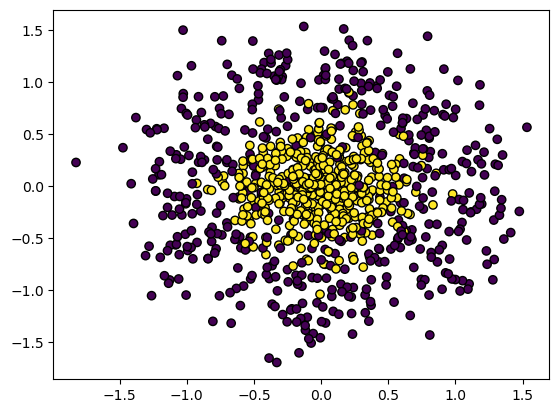

In [6]:
# Визуализируйте датасет

plt.scatter(X_circles['x1'], X_circles['x2'], c=y_circles, edgecolors='k')
plt.show()

In [7]:
# Разделите датасет на обучающую (60%) и тестовую (40%) выборки со стратификацией по целевой переменной
# Не забудьте зафиксировать RANDOM_STATE

X_circles_train, X_circles_test, y_circles_train, y_circles_test = train_test_split(
    X_circles, 
    y_circles, 
    test_size=0.4, 
    stratify=y_circles, 
    random_state=RANDOM_STATE
)

In [8]:
# Обучите дерево tree_circles (DecisionTreeClassifier)
# Не забудьте зафиксировать RANDOM_STATE

tree_circles = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_circles.fit(X_circles_train, y_circles_train)

DecisionTreeClassifier(random_state=42)

In [9]:
# На тестовой выборке постройте отчёт по метрикам классификации для tree_circles

# Получаем предсказания
y_circles_pred_tree = tree_circles.predict(X_circles_test)

# Выводим отчёт
print("Decision Tree Classification Report:")
print(classification_report(y_circles_test, y_circles_pred_tree, digits=4))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0     0.8049    0.8250    0.8148       200
           1     0.8205    0.8000    0.8101       200

    accuracy                         0.8125       400
   macro avg     0.8127    0.8125    0.8125       400
weighted avg     0.8127    0.8125    0.8125       400



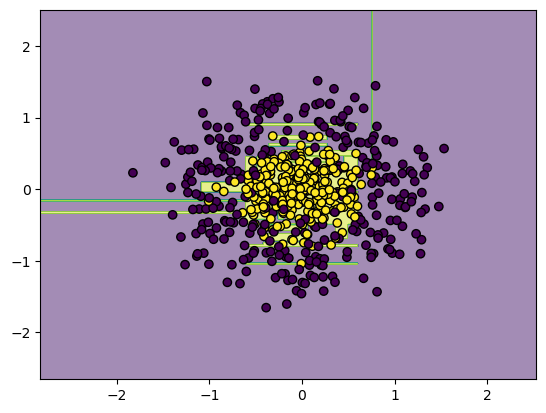

In [10]:
# Визуализируйте границу решений классификатора tree_circles на обучающей выборке

display_decision_boundary(tree_circles.predict, X_circles_train, y_circles_train)

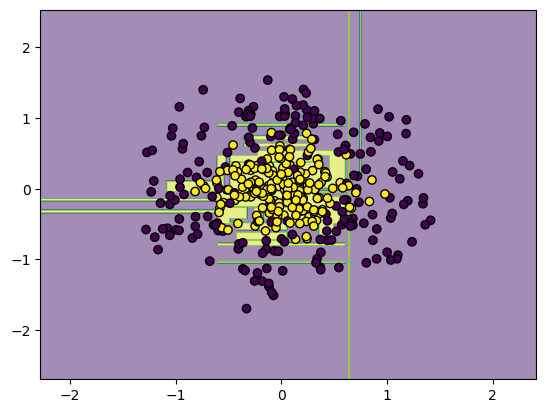

In [11]:
# Визуализируйте границу решений классификатора tree_circles на тестовой выборке

display_decision_boundary(tree_circles.predict, X_circles_test, y_circles_test)

In [12]:
# Обучите случайный лес rf_circles (RandomForestClassifier) с ограничением n_estimators=5
# Не забудьте зафиксировать RANDOM_STATE

rf_circles = RandomForestClassifier(n_estimators=5, random_state=RANDOM_STATE)
rf_circles.fit(X_circles_train, y_circles_train)

RandomForestClassifier(n_estimators=5, random_state=42)

In [13]:
# На тестовой выборке постройте отчёт по метрикам классификации для rf_circles

# Получаем предсказания случайного леса на тестовой выборке
y_circles_pred_rf = rf_circles.predict(X_circles_test)

# Выводим отчёт по метрикам
print("Random Forest Classification Report:")
print(classification_report(y_circles_test, y_circles_pred_rf, digits=4))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0     0.8434    0.8350    0.8392       200
           1     0.8366    0.8450    0.8408       200

    accuracy                         0.8400       400
   macro avg     0.8400    0.8400    0.8400       400
weighted avg     0.8400    0.8400    0.8400       400



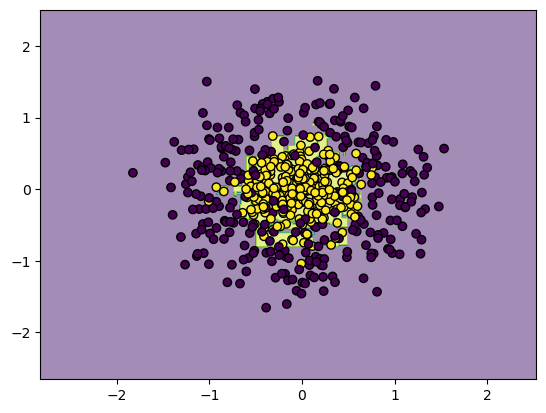

In [14]:
# Визуализируйте границу решений классификатора rf_circles на обучающей выборке

display_decision_boundary(rf_circles.predict, X_circles_train, y_circles_train)

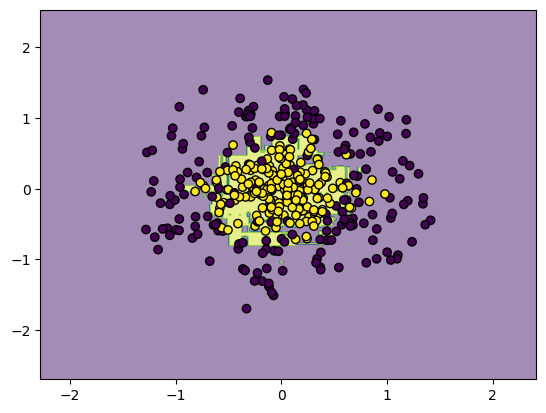

In [15]:
# Визуализируйте границу решений классификатора rf_circles на тестовой выборке

display_decision_boundary(rf_circles.predict, X_circles_test, y_circles_test)

**Разбор каждого утверждения:**

1. **"Все деревья в случайном лесе обучаются на идентичном, полном наборе обучающих данных."**
   - ❌ **НЕВЕРНО**
   - В случайном лесе каждое дерево обучается на своей **бутстрэп-подвыборке** (bootstrap sample), которая формируется случайным выбором объектов с возвращением. Подвыборки отличаются и не являются полным набором данных.

2. **"Случайный лес всегда будет демонстрировать результаты лучше, чем одиночное дерево решений, вне зависимости от количества деревьев в ансамбле и датасета."**
   - ❌ **НЕВЕРНО**
   - Случайный лес обычно работает лучше, но не **всегда**. При очень малом количестве деревьев (например, 1-2) или на некоторых простых датасетах одиночное дерево может показать сравнимые или даже лучшие результаты. Также при неправильной настройке параметров или при очень шумных данных разница может быть незначительной.

3. **"В задаче бинарной классификации с использованием случайного леса, состоящего из 5 деревьев, итоговым классом объекта будет считаться тот, за который проголосовали не менее 3 деревьев."**
   - ✅ **ВЕРНО**
   - При нечетном количестве деревьев (5) голосование большинством означает, что для принятия решения необходимо набрать **строго больше половины голосов**, то есть минимум 3 из 5 (так как 3 > 5/2). Это стандартный механизм голосования в классификации.

4. **"При обучении деревьев в случайном лесу для каждого дерева используются разные (но перекрывающиеся) подмножества обучающих данных, что повышает устойчивость ансамбля к переобучению."**
   - ✅ **ВЕРНО**
   - Бутстрэп-подвыборки действительно являются разными, но перекрывающимися (из-за выборки с возвращением). Это создаёт разнообразие деревьев, снижает корреляцию между ними и делает ансамбль более устойчивым к переобучению по сравнению с одиночным деревом.

---

**Ответ:** верные утверждения — **3 и 4**

**Разбор каждого утверждения:**

1. **"Параметр max_features в RandomForestClassifier влияет на корреляцию между деревьями в ансамбле: меньшее значение max_features приводит к меньшей корреляции между деревьями."**
   - ✅ **ВЕРНО**
   - Чем меньше `max_features` (количество случайно выбираемых признаков для каждого разбиения), тем больше разнообразие деревьев, так как каждое дерево "видит" разные подмножества признаков. Это снижает корреляцию между деревьями. При `max_features=M` (все признаки) деревья становятся более похожими, корреляция возрастает.

2. **"Преимущество случайного леса перед одиночным деревом заключается в снижении дисперсии (variance) предсказаний за счёт усреднения предсказаний нескольких некоррелированных моделей."**
   - ✅ **ВЕРНО**
   - Это ключевая идея бэггинга и случайного леса. Одиночное дерево имеет высокую дисперсию (сильно зависит от обучающих данных). Усреднение предсказаний множества некоррелированных (или слабо коррелированных) деревьев позволяет значительно снизить дисперсию, сохраняя при этом смещение (bias) на том же уровне.

3. **"Если бы все деревья в случайном лесе были идентичными (обучены на одинаковых данных с одинаковыми признаками), усреднение их предсказаний не дало бы никакого преимущества."**
   - ✅ **ВЕРНО**
   - Если все деревья идентичны, то усреднение (или голосование) просто вернёт тот же результат, что и одно дерево. Преимущество ансамбля достигается именно за счёт **разнообразия** моделей. Чем выше корреляция между деревьями, тем меньше выигрыш от объединения.

4. **"Если бы при обучении модели rf_circles (RandomForestClassifier) использовался параметр n_estimators=1, результаты были бы полностью идентичны результатам tree_circles (DecisionTreeClassifier)."**
   - ❌ **НЕВЕРНО**
   - Даже при `n_estimators=1` случайный лес не будет полностью идентичен обычному дереву решений, потому что:
     - В случайном лесе по умолчанию используется **бутстрэп-выборка** (`bootstrap=True`), даже для одного дерева. Дерево обучается не на всей обучающей выборке, а на её бутстрэп-копии (с повторениями).
     - Также по умолчанию в случайном лесе используется `max_features='sqrt'` (для классификации), то есть на каждом разбиении рассматривается случайное подмножество признаков, в то время как `DecisionTreeClassifier` по умолчанию использует все признаки (`max_features=None`).
   - Чтобы результаты были идентичны, нужно было бы явно задать `bootstrap=False` и `max_features=None`, но в условии этого нет.

---

**Ответ:** верные утверждения — **1, 2 и 3**

**Разбор каждого утверждения на основе метрик:**

1. **"Граница решений дерева tree_circles на тестовой выборке выглядит более сложной и изломанной, чем граница случайного леса rf_circles (см. визуализацию границы решений)."**
   - ✅ **ВЕРНО**
   - Это теоретически обосновано: дерево с неограниченной глубиной склонно к переобучению и строит сложную, изрезанную границу, стараясь идеально разделить обучающие точки. Случайный лес за счёт усреднения и бутстрэпа даёт более сглаженную границу. Это утверждение согласуется с теорией и типичным поведением моделей.

2. **"Ансамблевый подход показал значительное преимущество перед одиночным деревом решений для данной задачи: accuracy модели rf_circles на тестовой выборке выше аналогичного показателя модели tree_circles более, чем на 0.1."**
   - ❌ **НЕВЕРНО**
   - Accuracy дерева: 0.8125
   - Accuracy случайного леса: 0.8400
   - Разница: 0.8400 - 0.8125 = **0.0275**, что **меньше 0.1**. Преимущество есть, но оно не является "значительным" в терминах разницы более 0.1.

3. **"Обе модели показали приблизительно одинаковые результаты: accuracy моделей отличается менее, чем на 0.01."**
   - ❌ **НЕВЕРНО**
   - Разница в accuracy составляет 0.0275, что **больше 0.01**. Результаты не являются "приблизительно одинаковыми" с такой высокой точностью.

4. **"Модель rf_circles одинаково точно предсказывает оба класса: разница метрики precision на тестовой выборке для классов 0 и 1 не превышает 0.01."**
   - ✅ **ВЕРНО**
   - Precision для класса 0: 0.8434
   - Precision для класса 1: 0.8366
   - Разница: 0.8434 - 0.8366 = **0.0068**, что **меньше 0.01**
   - Модель действительно сбалансирована и показывает почти одинаковую точность предсказаний для обоих классов.

---

**Ответ:** верные утверждения — **1 и 4**

### **Алгоритм построения случайного леса**

Пусть $N$ — количество наблюдений (объектов) в обучающей выборке, $M$ — количество признаков, $m$ — неполное количество случайных признаков при обучении дерева, $k$ — количество деревьев в ансамбле.

* Для каждого дерева решений из $k$ деревьев в ансамбле:

    1. Генерируется бутстрэп-подвыборка путём случайного выбора $N$ объектов из обучающей выборки с возвращением (т.е. некоторые объекты могут повторяться несколько раз).

    2. На бутстрэп-подвыборке обучается дерево решений, причём:

        * При разбиении каждого узла дерева выбирается случайное подмножество признаков мощности $m$ (случайно выбирается $m$ из $M$ признаков).

        * Лучшее разбиение узла определяется только среди выбранных $m$ признаков.

        * Дерево строится до полного исчерпания бутстрэп-подвыборки и не подвергается процедуре прунинга.

### **Датасет *Titanic Dataset***

**Для решения заданий 2 — 4 рассмотрим датасет [Titanic Dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset).**

Набор данных предназначен для предсказания шансов выживания пассажиров трагически затонувшего в 1912 году корабля "Титаник" на основе имеющейся информации о пассажирах.

Одной из особенностей датасета является наличие **пропущенных значений**.

Целевая переменная — Survived:

* 1 — пассажир выжил (целевой класс).

* 0 — пассажир погиб в катастрофе.

Датасет содержит признаки:

* PassengerId — уникальный идентификатор пассажира.

* Pclass — класс билета (1, 2 или 3).

* Name — имя пассажира.

* Sex — пол пассажира.

* Age — возраст пассажира.

* SibSp — количество братьев, сестёр или супругов на борту.

* Parch — количество родителей или детей на борту.

* Ticket — номер билета.

* Fare — стоимость билета.

* Cabin — номер каюты.

* Embarked — порт посадки (C = Cherbourg, Q = Queenstown, S = Southampton).

### ***Задание 2***

Выполните предобработку датасета (см. код).

Используя обучающую выборку, сгенерируйте 5 бутстрэп-подвыброк ($k=5$), используя функцию [choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) (путём случайного выбора индексов датасета `X_titanic_train` с повторениями).

На каждой из сгенерированных подвыборок обучите дерево DecisionTreeClassifier с неограниченной глубиной и с параметрами:

* **random_state=i**, где $i=0,...,4$ — индекс дерева (индекс подвыборки)

* **max_features=5** — параметр, задающий максимальное число случайных признаков, которое рассматривается для наилучшего разбиения в каждом узле дерева.

Используя обученные деревья решений, предскажите вероятности выживания пассажиров **в тестовой выборке** (запишите предсказанные вероятности в `titanic_trees_y_test_proba`) и посчитайте AUC для предсказания каждого из деревьев решений в отдельности.

Рассчитайте среднее значение AUC, если прогноз на тестовой выборке осуществляется каждым деревом по отдельности.

Рассматривая обученные деревья как ансамбль, постройте прогноз вероятностей для этого ансамбля (случайного леса) **на тестовой выборке** — **усредните (найдите среднее) значения вероятностей выживания**, предсказанные деревьями, входящими в ансамбль.

Рассчитайте значение AUC для прогноза ансамбля (случайного леса) на тестовой выборке.

Обучите модель случайного леса `rf_titanic_5` (RandomForestClassifier) c параметром n_estimators=5 (5 деревьев). 

Рассчитайте AUC модели `rf_titanic_5` на **тестовой выборке**.

Сравните значения AUC модели `rf_titanic_5`, среднего AUC для деревьев и AUC ансамбля (случайного леса).

In [16]:
# Считайте набор данных

df_titanic = pd.read_csv('titanic.csv')
df_titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [17]:
# Удалите колонки, не несущие существенной информации: PassengerId, Name, Ticket, Cabin

df_titanic = df_titanic.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [18]:
# Убедитесь, что в датасете присутствуют пропуски в данных

print("Пропуски в данных:")
print(df_titanic.isnull().sum())
print("\nИнформация о датасете:")
print(df_titanic.info())

Пропуски в данных:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
None


In [19]:
# Посчитайте доли пропусков во всей выборке

titanic_nan_info = pd.DataFrame({'NaN share': df_titanic.isnull().mean()})
titanic_nan_info = titanic_nan_info[titanic_nan_info['NaN share'] != 0.0]

print("Признаки с пропусками и их доля:")
print(titanic_nan_info)

Признаки с пропусками и их доля:
          NaN share
Age        0.198653
Embarked   0.002245


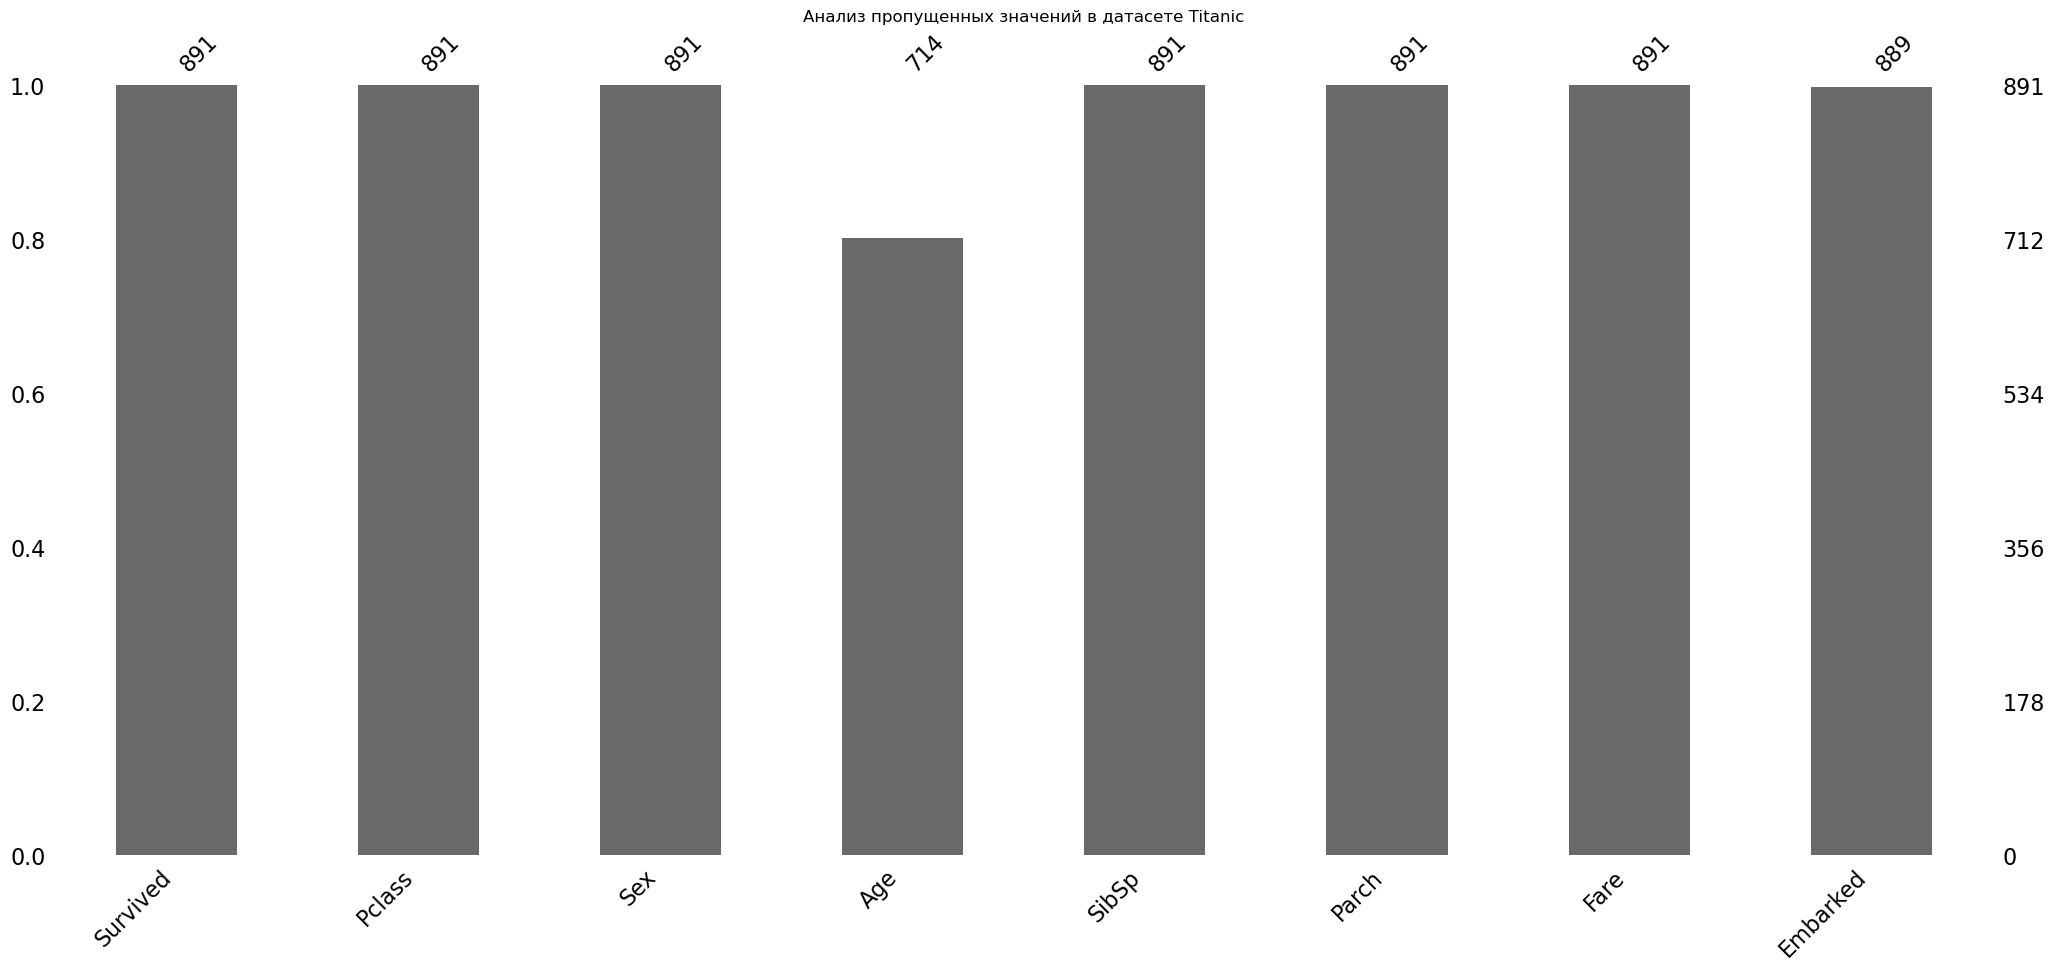

In [20]:
# Выполните визуальный анализ пропущенных значений во всей выборке с помощью msno.bar

import missingno as msno
import matplotlib.pyplot as plt

# Выполните визуальный анализ пропущенных значений во всей выборке с помощью msno.bar
plt.figure(figsize=(10, 6))
msno.bar(df_titanic)
plt.title('Анализ пропущенных значений в датасете Titanic')
plt.show()

Получили столбчатую диаграмму, показывающую:
- Количество не-пропущенных значений для каждого признака
- Долю пропусков визуально
- Относительный масштаб пропусков между признаками

Ожидаемая картина:
- `Age` будет иметь заметный блок пропусков (~20%)
- `Embarked` — небольшой блок пропусков (единичные записи)
- Остальные признаки (`Pclass`, `Sex`, `SibSp`, `Parch`, `Fare`) не содержат пропусков

<Figure size 1200x600 with 0 Axes>

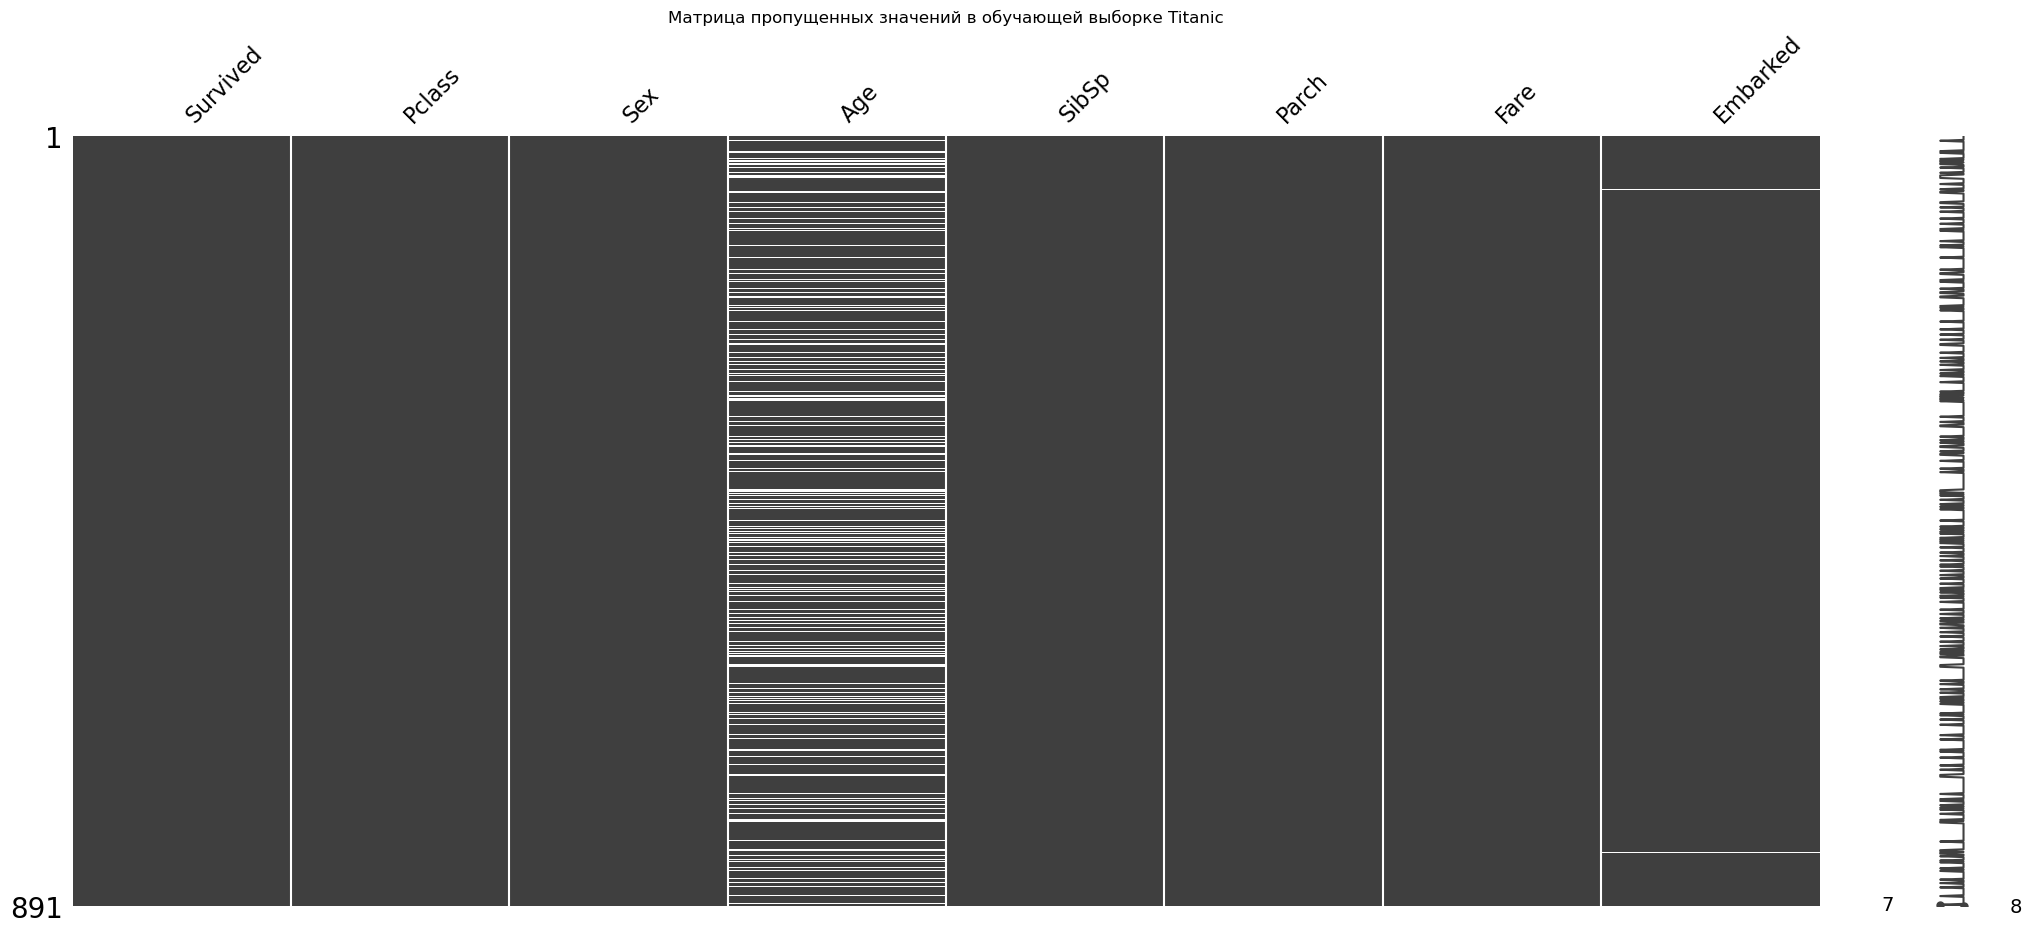

In [21]:
# Выполните визуальный анализ пропущенных значений в обучающей выборке с помощью msno.matrix

plt.figure(figsize=(12, 6))
msno.matrix(df_titanic)
plt.title('Матрица пропущенных значений в обучающей выборке Titanic')
plt.show()

Функция `msno.matrix` показывает:
- **Белые полосы/пробелы** — места, где есть пропуски в данных
- **Справа спрайт-график** — показывает паттерны пропусков
- **Плотность заполнения** — чем темнее область, тем больше не-пропущенных значений

Это позволяет визуально оценить:
- Есть ли систематические паттерны в пропусках (например, пропуски в `Age` могут коррелировать с другими признаками)
- Распределение пропусков по строкам обучающей выборки

Ожидаемая картина:
- В `Age` будут видны "разрывы" примерно в 20% строк
- В `Embarked` — очень редкие разрывы (возможно, 1-2 строки)
- В остальных признаках (`Sex`, `Pclass`, `SibSp`, `Parch`, `Fare`) нет пропусков.

In [22]:
# Создайте список категориальных переменных (не включая целевую переменную)

titanic_cat_feat = ['Pclass', 'Sex', 'Embarked']

In [23]:
# Выделите объясняемый фактор в отдельную переменную

X_titanic = df_titanic.drop('Survived', axis=1)
y_titanic = df_titanic['Survived']

In [24]:
# Закодируйте категориальные признаки числами 0 и 1 с помощью OneHotEncoder

titanic_encoder = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')

# Применяем кодирование к категориальным признакам
X_titanic_encoded = titanic_encoder.fit_transform(X_titanic[titanic_cat_feat])

# Удаляем исходные категориальные признаки и добавляем закодированные
X_titanic = X_titanic.drop(titanic_cat_feat, axis=1)
X_titanic = pd.concat([X_titanic, X_titanic_encoded], axis=1)

print("Результат после кодирования:")
print(f"Форма X_titanic: {X_titanic.shape}")
print(f"\nПервые 5 строк закодированных данных:")
print(X_titanic.head())
print(f"\nПризнаки после кодирования:")
print(X_titanic.columns.tolist())

Результат после кодирования:
Форма X_titanic: (891, 10)

Первые 5 строк закодированных данных:
    Age  SibSp  Parch     Fare  Pclass_2  Pclass_3  Sex_male  Embarked_Q  \
0  22.0      1      0   7.2500       0.0       1.0       1.0         0.0   
1  38.0      1      0  71.2833       0.0       0.0       0.0         0.0   
2  26.0      0      0   7.9250       0.0       1.0       0.0         0.0   
3  35.0      1      0  53.1000       0.0       0.0       0.0         0.0   
4  35.0      0      0   8.0500       0.0       1.0       1.0         0.0   

   Embarked_S  Embarked_nan  
0         1.0           0.0  
1         0.0           0.0  
2         1.0           0.0  
3         1.0           0.0  
4         1.0           0.0  

Признаки после кодирования:
['Age', 'SibSp', 'Parch', 'Fare', 'Pclass_2', 'Pclass_3', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Embarked_nan']


In [25]:
# Разделите датасет на обучающую (60%) и тестовую (40%) выборки со стратификацией по целевой переменной
# Не забудьте зафиксировать RANDOM_STATE

X_titanic_train, X_titanic_test, y_titanic_train, y_titanic_test = train_test_split(
    X_titanic, 
    y_titanic, 
    test_size=0.4, 
    stratify=y_titanic, 
    random_state=RANDOM_STATE
)

print(f"Размер обучающей выборки: {X_titanic_train.shape}")
print(f"Размер тестовой выборки: {X_titanic_test.shape}")
print(f"\nРаспределение целевой переменной в обучающей выборке:")
print(y_titanic_train.value_counts(normalize=True))
print(f"\nРаспределение целевой переменной в тестовой выборке:")
print(y_titanic_test.value_counts(normalize=True))

Размер обучающей выборки: (534, 10)
Размер тестовой выборки: (357, 10)

Распределение целевой переменной в обучающей выборке:
Survived
0    0.616105
1    0.383895
Name: proportion, dtype: float64

Распределение целевой переменной в тестовой выборке:
Survived
0    0.616246
1    0.383754
Name: proportion, dtype: float64


In [26]:
# Используя обучающую выборку, сгенерируйте 5 бутстрэп-подвыброк, используя функцию choice

# Не забудьте зафиксировать RANDOM_STATE (с помощью переменной rng)
rng = np.random.RandomState(RANDOM_STATE)

k = 5 # Число деревьев в ансамбле (число бутстрэп-подвыброк)

train_N = X_titanic_train.shape[0] # Размер обучающей выборки

train_idx = list(range(train_N)) # Список с индексами наблюдений обучающей выборки

# Выполните случайный выбор индексов train_idx с повторениями
titanic_bootstraps = [rng.choice(train_idx, size=train_N, replace=True) for _ in range(k)]

print(f"Размер обучающей выборки: {train_N}")
print(f"Сгенерировано {len(titanic_bootstraps)} бутстрэп-подвыборок")
print(f"\nПример индексов первой бутстрэп-подвыборки (первые 20):")
print(titanic_bootstraps[0][:20])
print(f"\nУникальных индексов в первой подвыборке: {len(np.unique(titanic_bootstraps[0]))}")
print(f"Количество повторяющихся индексов: {train_N - len(np.unique(titanic_bootstraps[0]))}")

Размер обучающей выборки: 534
Сгенерировано 5 бутстрэп-подвыборок

Пример индексов первой бутстрэп-подвыборки (первые 20):
[102 435 270 106  71  20 121 466 214 330 458  87 372  99 130 308 343 491
 413 385]

Уникальных индексов в первой подвыборке: 330
Количество повторяющихся индексов: 204


In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

# На каждой из бутстрэп-подвыборок обучите дерево DecisionTreeClassifier с неограниченной глубиной и с параметрами
#   random_state=i
#   max_features=5
# Для каждого дерева используйте отдельную бутстрэп-подвыборку
# После построения каждого дерева предскажите вероятности выживания пассажиров в тестовой выборке и посчитайте AUC

titanic_trees_y_test_proba = [] # Список для записи векторов предсказаний деревьев
titanic_trees_roc_auc = [] # Список для записи AUC деревьев

for i in range(k):
    # Формируем бутстрэп-подвыборку по индексам
    X_titanic_fold_train = X_titanic_train.iloc[titanic_bootstraps[i]]
    y_titanic_fold_train = y_titanic_train.iloc[titanic_bootstraps[i]]
    
    # Обучаем дерево
    tree_titanic_fold = DecisionTreeClassifier(
        random_state=i,
        max_features=5
    ).fit(X_titanic_fold_train, y_titanic_fold_train)
    
    # Предсказываем вероятности для тестовой выборки
    y_test_proba_tree_titanic_fold = tree_titanic_fold.predict_proba(X_titanic_test)[:, 1]
    titanic_trees_y_test_proba.append(y_test_proba_tree_titanic_fold)
    
    # Считаем AUC
    roc_auc_tree_titanic_fold = roc_auc_score(y_titanic_test, y_test_proba_tree_titanic_fold)
    titanic_trees_roc_auc.append(roc_auc_tree_titanic_fold)
    
    print('AUC дерева {}: {:.4f}'.format(i, roc_auc_tree_titanic_fold))

titanic_trees_y_proba = np.array(titanic_trees_y_test_proba)

print(f"\nСреднее AUC для отдельных деревьев: {np.mean(titanic_trees_roc_auc):.4f}")
print(f"Стандартное отклонение AUC: {np.std(titanic_trees_roc_auc):.4f}")

AUC дерева 0: 0.7563
AUC дерева 1: 0.7271
AUC дерева 2: 0.7767
AUC дерева 3: 0.7172
AUC дерева 4: 0.7004

Среднее AUC для отдельных деревьев: 0.7355
Стандартное отклонение AUC: 0.0275


In [28]:
# Удостоверьтесь, что размерность массива titanic_trees_y_proba — (5, 357)

titanic_trees_y_proba.shape

(5, 357)

In [29]:
# Рассчитайте среднее значение AUC, если прогноз на тестовой выборке осуществляется каждым деревом по отдельности

mean_auc_trees = np.mean(titanic_trees_roc_auc)

print(f"Среднее значение AUC для отдельных деревьев: {mean_auc_trees:.4f}")
print(f"Детальные значения AUC по деревьям: {[f'{x:.4f}' for x in titanic_trees_roc_auc]}")

Среднее значение AUC для отдельных деревьев: 0.7355
Детальные значения AUC по деревьям: ['0.7563', '0.7271', '0.7767', '0.7172', '0.7004']


In [30]:
# Посчитайте прогноз случайного леса как усреднённое значение вероятностей, 
# предсказанных деревьями ансамбля

y_test_proba_forest_titanic = np.mean(titanic_trees_y_proba, axis=0)

print(f"Форма усреднённых предсказаний: {y_test_proba_forest_titanic.shape}")
print(f"Первые 10 усреднённых вероятностей:")
print(y_test_proba_forest_titanic[:10])

Форма усреднённых предсказаний: (357,)
Первые 10 усреднённых вероятностей:
[1.   0.2  0.45 0.2  1.   0.4  0.   0.79 1.   0.8 ]


In [31]:
# Рассчитайте значение AUC для прогноза ансамбля (случайного леса) на тестовой выборке

roc_auc_ensemble = roc_auc_score(y_titanic_test, y_test_proba_forest_titanic)

print(f"AUC ансамбля (усреднённые предсказания): {roc_auc_ensemble:.4f}")

AUC ансамбля (усреднённые предсказания): 0.8244


In [32]:
# Обучите модель RandomForestClassifier c параметром n_estimators=5
# Не забудьте зафиксировать RANDOM_STATE

rf_titanic_5 = RandomForestClassifier(n_estimators=5, random_state=RANDOM_STATE)
rf_titanic_5.fit(X_titanic_train, y_titanic_train)

print("Модель RandomForestClassifier обучена")
print(f"Количество деревьев: {rf_titanic_5.n_estimators}")
print(f"Параметры модели: max_features={rf_titanic_5.max_features} (по умолчанию 'sqrt')")

Модель RandomForestClassifier обучена
Количество деревьев: 5
Параметры модели: max_features=sqrt (по умолчанию 'sqrt')


In [33]:
# Рассчитайте AUC модели rf_titanic_5 на тестовой выборке

# Получаем предсказания вероятностей
y_test_proba_rf_5 = rf_titanic_5.predict_proba(X_titanic_test)[:, 1]

# Рассчитываем AUC
roc_auc_rf_5 = roc_auc_score(y_titanic_test, y_test_proba_rf_5)

print(f"AUC модели RandomForestClassifier (n_estimators=5): {roc_auc_rf_5:.4f}")

AUC модели RandomForestClassifier (n_estimators=5): 0.8345


### **RandomizedSearchCV**

[RandomizedSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html) — метод подбора оптимальных гиперпараметров модели, суть которого состоит в переборе случайных комбинаций значений параметров из заданных диапазонов или распределений вместо полного перебора всех возможных комбинаций (как это реализовано в GridSearchCV).

**RandomizedSearchCV и GridSearchCV**:

* **RandomizedSearchCV** выбирает комбинации случайно. Это снижает вычислительные затраты и позволяет находить приемлемые (иногда лучшие) гиперпараметры при меньших вычислительных затратах. **Параметр n_iter** указывает число случайных комбинаций гиперпараметров, которые будут протестированы в процессе подбора.

* **GridSearchCV** перебирает все комбинации значений гиперпараметров. Это гарантирует нахождение результата внутри сетки, но требует много времени, особенно при большом числе параметров или возможных значений.

Подробнее можно изучить по **ссылке:**

* [Рандомизированная оптимизация параметров | scikit-learn.ru](https://scikit-learn.ru/stable/modules/grid_search.html#randomized-parameter-search)

### ***Задание 3***

**ВНИМАНИЕ:** Для решения этого задания используйте:

* Обучающую и тестовую выборку из задания 2: `X_titanic_train`, `X_titanic_test`, `y_titanic_train`, `y_titanic_test`.

На обучающей выборке обучите две модели, предварительно подобрав оптимальные значения гиперпараметров обучения **с помощью RandomizedSearchCV** (n_iter=50 — 50 итераций):

* `tree_titanic` — дерево DecisionTreeClassifier.

* `rf_titanic` — случайный лес RandomForestClassifier.

Выведите оптимальные гиперпараметры обучения моделей `tree_titanic` и `rf_titanic` и номера итераций, на которых были достигнуты оптимальные комбинации параметров в рамках подбора с помощью RandomizedSearchCV.

Для моделей `tree_titanic` и `rf_titanic` **на тестовой выборке** постройте отчёт по метрикам классификации и рассчитайте значения AUC.

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

# Обучите модель tree_titanic с оптимальными гиперпараметрами
# Оптимальные гиперпараметры обучения подберите с помощью RandomizedSearchCV
# Не забудьте зафиксировать RANDOM_STATE

params = {
    'max_depth': range(5, 15),
    'min_samples_split': range(2, 10),
    'min_samples_leaf': range(2, 10),
}
n_iter = 50
scoring = 'roc_auc'
cv = 5

cv_tree_titanic = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_distributions=params,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    random_state=RANDOM_STATE
).fit(X_titanic_train, y_titanic_train)

tree_titanic = cv_tree_titanic.best_estimator_

# Выводим результаты
print("=== DecisionTreeClassifier - результаты RandomizedSearchCV ===")
print(f"Лучшие гиперпараметры: {cv_tree_titanic.best_params_}")
print(f"Лучшее значение AUC на кросс-валидации: {cv_tree_titanic.best_score_:.4f}")
print(f"Итерация с лучшими параметрами: {cv_tree_titanic.best_index_}")
print(f"Всего итераций: {n_iter}")

=== DecisionTreeClassifier - результаты RandomizedSearchCV ===
Лучшие гиперпараметры: {'min_samples_split': 4, 'min_samples_leaf': 2, 'max_depth': 5}
Лучшее значение AUC на кросс-валидации: 0.8272
Итерация с лучшими параметрами: 38
Всего итераций: 50


In [35]:
# Выведите оптимальные гиперпараметры обучения tree_titanic и номер итерации, 
# на котором они были достигнуты

print("=== DecisionTreeClassifier - результаты RandomizedSearchCV ===")
print(f"Оптимальные параметры DecisionTreeClassifier на итерации {cv_tree_titanic.best_index_}: {cv_tree_titanic.best_params_}")
print(f"Значение AUC на кросс-валидации для лучшей модели: {cv_tree_titanic.best_score_:.4f}")
print(f"Всего протестировано комбинаций: {n_iter}")

=== DecisionTreeClassifier - результаты RandomizedSearchCV ===
Оптимальные параметры DecisionTreeClassifier на итерации 38: {'min_samples_split': 4, 'min_samples_leaf': 2, 'max_depth': 5}
Значение AUC на кросс-валидации для лучшей модели: 0.8272
Всего протестировано комбинаций: 50


In [36]:
# Постройте отчёт по метрикам классификации для модели tree_titanic на тестовой выборке

# Получаем предсказания для тестовой выборки
y_test_pred_tree = tree_titanic.predict(X_titanic_test)
y_test_proba_tree = tree_titanic.predict_proba(X_titanic_test)[:, 1]

# Выводим отчёт по метрикам
print("=== DecisionTreeClassifier - отчёт на тестовой выборке ===")
print(classification_report(y_titanic_test, y_test_pred_tree, digits=4))


=== DecisionTreeClassifier - отчёт на тестовой выборке ===
              precision    recall  f1-score   support

           0     0.7907    0.9273    0.8536       220
           1     0.8384    0.6058    0.7034       137

    accuracy                         0.8039       357
   macro avg     0.8145    0.7666    0.7785       357
weighted avg     0.8090    0.8039    0.7959       357



In [37]:
# Рассчитайте значение метрики AUC для модели tree_titanic на тестовой выборке

# Считаем AUC
auc_tree = roc_auc_score(y_titanic_test, y_test_proba_tree)

print(f"AUC на тестовой выборке: {auc_tree:.4f}")

AUC на тестовой выборке: 0.8402


In [38]:
from sklearn.ensemble import RandomForestClassifier

# Обучите модель rf_titanic с оптимальными гиперпараметрами
# Оптимальные гиперпараметры обучения подберите с помощью RandomizedSearchCV
# Не забудьте зафиксировать RANDOM_STATE

params = {
    'n_estimators': range(5, 200),
    'min_samples_split': range(2, 10),
    'min_samples_leaf': range(2, 10),
}
n_iter = 50
scoring = 'roc_auc'
cv = 5

cv_rf_titanic = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=params,
    n_iter=n_iter,
    scoring=scoring,
    cv=cv,
    random_state=RANDOM_STATE
).fit(X_titanic_train, y_titanic_train)

rf_titanic = cv_rf_titanic.best_estimator_

# Выводим результаты
print("=== RandomForestClassifier - результаты RandomizedSearchCV ===")
print(f"Лучшие гиперпараметры: {cv_rf_titanic.best_params_}")
print(f"Лучшее значение AUC на кросс-валидации: {cv_rf_titanic.best_score_:.4f}")
print(f"Итерация с лучшими параметрами: {cv_rf_titanic.best_index_}")
print(f"Всего итераций: {n_iter}")

=== RandomForestClassifier - результаты RandomizedSearchCV ===
Лучшие гиперпараметры: {'n_estimators': 58, 'min_samples_split': 8, 'min_samples_leaf': 8}
Лучшее значение AUC на кросс-валидации: 0.8620
Итерация с лучшими параметрами: 17
Всего итераций: 50


In [39]:
# Выведите оптимальные гиперпараметры обучения rf_titanic и номер итерации, на котором они были достигнуты
# Выведите оптимальные гиперпараметры обучения rf_titanic и номер итерации, на котором они были достигнуты

print("=== RandomForestClassifier - оптимальные параметры ===")
print(f'Оптимальные параметры RandomForestClassifier на итерации {cv_rf_titanic.best_index_}: {cv_rf_titanic.best_params_}')
print(f'Лучшее значение AUC на кросс-валидации: {cv_rf_titanic.best_score_:.4f}')
print(f"Всего протестировано комбинаций: {n_iter}")

print("\n" + "="*50)
print("Сравнение результатов RandomizedSearchCV:")
print("="*50)
print(f"DecisionTreeClassifier - итерация {cv_tree_titanic.best_index_}: {cv_tree_titanic.best_params_}")
print(f"  Лучшее AUC на CV: {cv_tree_titanic.best_score_:.4f}")
print(f"RandomForestClassifier - итерация {cv_rf_titanic.best_index_}: {cv_rf_titanic.best_params_}")
print(f"  Лучшее AUC на CV: {cv_rf_titanic.best_score_:.4f}")

=== RandomForestClassifier - оптимальные параметры ===
Оптимальные параметры RandomForestClassifier на итерации 17: {'n_estimators': 58, 'min_samples_split': 8, 'min_samples_leaf': 8}
Лучшее значение AUC на кросс-валидации: 0.8620
Всего протестировано комбинаций: 50

Сравнение результатов RandomizedSearchCV:
DecisionTreeClassifier - итерация 38: {'min_samples_split': 4, 'min_samples_leaf': 2, 'max_depth': 5}
  Лучшее AUC на CV: 0.8272
RandomForestClassifier - итерация 17: {'n_estimators': 58, 'min_samples_split': 8, 'min_samples_leaf': 8}
  Лучшее AUC на CV: 0.8620


In [40]:
# Постройте отчёт по метрикам классификации для модели rf_titanic на тестовой выборке

from sklearn.metrics import classification_report, roc_auc_score

# Получаем предсказания для тестовой выборки
y_test_pred_rf = rf_titanic.predict(X_titanic_test)
y_test_proba_rf = rf_titanic.predict_proba(X_titanic_test)[:, 1]

# Выводим отчёт по метрикам
print("=== RandomForestClassifier - отчёт на тестовой выборке ===")
print(classification_report(y_titanic_test, y_test_pred_rf, digits=4))

=== RandomForestClassifier - отчёт на тестовой выборке ===
              precision    recall  f1-score   support

           0     0.8015    0.9727    0.8789       220
           1     0.9333    0.6131    0.7401       137

    accuracy                         0.8347       357
   macro avg     0.8674    0.7929    0.8095       357
weighted avg     0.8521    0.8347    0.8256       357



In [41]:
# Рассчитайте значение метрики AUC для модели rf_titanic на тестовой выборке

# Считаем AUC
auc_rf = roc_auc_score(y_titanic_test, y_test_proba_rf)

print(f"AUC на тестовой выборке: {auc_rf:.4f}")

AUC на тестовой выборке: 0.8606


---

**1. "Оптимизированное дерево tree_titanic показало лучший результат с точки зрения AUC на тестовой выборке, чем модель rf_titanic_5 из задания 2"**

- AUC `tree_titanic` (задание 3): **0.8402**
- AUC `rf_titanic_5` (задание 2): **0.8345**

0.8402 > 0.8345, следовательно, оптимизированное дерево действительно показало **лучший** результат.

✅ **ВЕРНО**

---

**2. "Accuracy модели rf_titanic на тестовой выборке заметно выше, чем аналогичный показатель у tree_titanic: абсолютная разница значений accuracy больше 0.05."**

- Accuracy `tree_titanic`: **0.8039**
- Accuracy `rf_titanic`: **0.8347**
- Разница: **0.0308** (< 0.05)

❌ **НЕВЕРНО**

---

**3. "Оптимальное (с точки зрения оптимизации с помощью RandomizedSearchCV) количество деревьев n_estimators для rf_titanic больше 50."**

- Оптимальное `n_estimators`: **58** (> 50)

✅ **ВЕРНО**

---

**4. "Оптимальное (с точки зрения оптимизации с помощью RandomizedSearchCV) значение max_depth для tree_titanic является минимальным в заданном диапазоне."**

- Диапазон: **range(5, 15)**
- Оптимальное `max_depth`: **5** (минимальное значение)

✅ **ВЕРНО**

---

**Итоговый ответ:** верные утверждения — **1, 3 и 4**

### **Isolation Forest**

Isolation Forest — это алгоритм машинного обучения без учителя (unsupervised machine learning), предназначенный для обнаружения аномалий. В отличие от методов, основанных на расстояниях или плотностях, Isolation Forest **использует ансамбль решающих деревьев** для изоляции аномальных точек. Ключевая идея этого алгоритма состоит в том, что аномальные наблюдения можно "изолировать" за меньшее число шагов, чем "обычные" данные, поскольку аномальные наблюдения встречаются редко и имеют необычные значения признаков.

Для определения аномальных значений в Isolation Forest используется **оценка аномальности**:

$$s(x,n)=2^{-\frac{\mathbb{E}(h(x))}{c(x)}}$$

где $\mathbb{E}(h(x))$ — средняя глубина (число шагов до изоляции наблюдения) по всем деревьям, $c(x)$ — нормирующая константа (зависит от размера данных).

Подробнее можно изучить по **ссылке:**

* [How to perform anomaly detection with the Isolation Forest algorithm | towardsdatascience.com](https://towardsdatascience.com/how-to-perform-anomaly-detection-with-the-isolation-forest-algorithm-e8c8372520bc/)

### **Датасет *Credit Card Fraud Detection***

**Для решения задания 4 рассмотрим датасет [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).**

Датасет предназначен для обнаружения мошеннических операций (фрод-операций) с кредитными картами. В нем собраны данные по транзакциям, совершенным европейскими владельцами карт за два дня в сентябре 2013 года. Данные о транзакциях представлены в виде числовых переменных, полученных в результате преобразования методом главных компонент (PCA). 

Целевая переменная — Class (метка мошеннической операции):

* 1 — фрод-транзакция (аномальное значение).

* 0 — транзакция не является мошеннической.

Датасет характеризуется сильным дисбалансом классов (мошенничество — очень редкое событие): среди 284807 транзакций было выявлено 492 фрод-операций (0.172% от всех транзакций). 

### ***Задание 4***

Обучите модель `if_fraud` (IsolationForest) **на всей выборке** c 500 деревьями в ансамбле и определите аномальные наблюдения в выборке.

Рассматривая задачу как задачу классификации, где **аномальное значение соответствует случаю мошенничества (Class = 1)**, на всей выборке для модели `if_fraud` постройте матрицу ошибок и отчёт по метрикам классификации. Рассчитайте долю мошеннических транзакций, которую смогла выявить модель.

**ВНИМАНИЕ:** Поскольку алгоритм Isolation Forest относится к классу задач машинного обучения без учителя, при обучении модели метки классов (вектор истинных значений объясняемой переменной) не используются. Метки классов нужны в рамках данной задачи с целью оценки того, насколько точно модель Isolation Forest смогла выявить мошеннические операции среди всех транзакций.

*Важным параметром в модели IsolationForest является параметр contamination. Он определяет **ожидаемую долю аномалий в данных**, то есть то, сколько процентов объектов модель должна считать "аномальными" после обучения. В рамках данного задания рассматривается стандартное значение contamination.*

In [42]:
# Считайте набор данных

df_fraud = pd.read_csv('creditcard.csv')
df_fraud

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [43]:
# Выделите объясняемый фактор в отдельную переменную

X_fraud = df_fraud.drop('Class', axis=1)
y_fraud = df_fraud['Class']

# Посмотрим на структуру данных
print("Размер датасета:", df_fraud.shape)
print("\nРаспределение целевой переменной (Class):")
print(y_fraud.value_counts())
print(f"\nДоля мошеннических транзакций: {y_fraud.mean()*100:.4f}%")

Размер датасета: (284807, 31)

Распределение целевой переменной (Class):
Class
0    284315
1       492
Name: count, dtype: int64

Доля мошеннических транзакций: 0.1727%


In [44]:
# Обучите модель if_fraud с 500 деревьями в ансамбле
# Метки классов y_fraud не используются при обучении
# Не забудьте зафиксировать RANDOM_STATE

if_fraud = IsolationForest(
    n_estimators=500,
    random_state=RANDOM_STATE,
    contamination='auto'  # стандартное значение (по умолчанию 'auto')
).fit(X_fraud)

print("Модель Isolation Forest обучена")
print(f"Количество деревьев в ансамбле: {if_fraud.n_estimators}")
print(f"Параметр contamination: {if_fraud.contamination}")
print(f"Смещение (offset): {if_fraud.offset_:.4f}")

Модель Isolation Forest обучена
Количество деревьев в ансамбле: 500
Параметр contamination: auto
Смещение (offset): -0.5000


In [45]:
# С помощью модели if_fraud определите аномальные наблюдения
#   1 — не аномальное наблюдение
#   -1 — аномальное наблюдение

pred_if_fraud = if_fraud.predict(X_fraud)

# Подсчитываем количество аномальных и нормальных наблюдений
unique, counts = np.unique(pred_if_fraud, return_counts=True)

print("Результаты предсказания Isolation Forest:")
for label, count in zip(unique, counts):
    if label == 1:
        print(f"  Не аномальные наблюдения (1): {count} ({count/len(pred_if_fraud)*100:.2f}%)")
    else:
        print(f"  Аномальные наблюдения (-1): {count} ({count/len(pred_if_fraud)*100:.2f}%)")

print(f"\nОбщее количество наблюдений: {len(pred_if_fraud)}")
print(f"Доля аномалий, выявленных моделью: {counts[unique == -1][0]/len(pred_if_fraud)*100:.4f}%")

Результаты предсказания Isolation Forest:
  Аномальные наблюдения (-1): 10019 (3.52%)
  Не аномальные наблюдения (1): 274788 (96.48%)

Общее количество наблюдений: 284807
Доля аномалий, выявленных моделью: 3.5178%


In [46]:
# Перейдите от прогноза аномальных наблюдений к целевой переменной:
#   1 (не аномальное наблюдение) —> 0 (обычная транзакция)
#   -1 (аномальное наблюдение) —> 1 (мошенническая транзакция)

y_pred_if_fraud = (pred_if_fraud == -1).astype(int)

# Проверяем результат
print("Преобразование предсказаний:")
print(f"Уникальные значения в pred_if_fraud: {np.unique(pred_if_fraud)}")
print(f"Уникальные значения в y_pred_if_fraud: {np.unique(y_pred_if_fraud)}")
print(f"\nРаспределение после преобразования:")
print(f"  Обычные транзакции (0): {sum(y_pred_if_fraud == 0)} ({sum(y_pred_if_fraud == 0)/len(y_pred_if_fraud)*100:.2f}%)")
print(f"  Мошеннические транзакции (1): {sum(y_pred_if_fraud == 1)} ({sum(y_pred_if_fraud == 1)/len(y_pred_if_fraud)*100:.2f}%)")

Преобразование предсказаний:
Уникальные значения в pred_if_fraud: [-1  1]
Уникальные значения в y_pred_if_fraud: [0 1]

Распределение после преобразования:
  Обычные транзакции (0): 274788 (96.48%)
  Мошеннические транзакции (1): 10019 (3.52%)


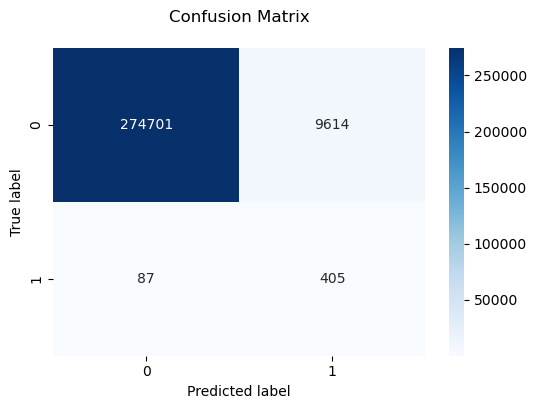


Детали матрицы ошибок:
True Negatives (TN): 274701
False Positives (FP): 9614
False Negatives (FN): 87
True Positives (TP): 405


In [47]:
# Постройте матрицу ошибок
cf_matrix = confusion_matrix(y_fraud, y_pred_if_fraud)

plt.figure(figsize=(6, 4))
ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g')
ax.set_title('Confusion Matrix\n')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.show()

# Выводим числовые значения матрицы ошибок
tn, fp, fn, tp = cf_matrix.ravel()
print("\nДетали матрицы ошибок:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

Пояснение:
- **TN (True Negatives)**: обычные транзакции, правильно классифицированные как обычные
- **FP (False Positives)**: обычные транзакции, ошибочно классифицированные как мошеннические
- **FN (False Negatives)**: мошеннические транзакции, которые модель пропустила
- **TP (True Positives)**: мошеннические транзакции, правильно выявленные моделью

Готовы перейти к отчёту по метрикам классификации?

In [48]:
# Постройте отчёт по метрикам классификации

print("=== Isolation Forest - отчёт по метрикам классификации ===")
print(classification_report(y_fraud, y_pred_if_fraud, digits=4, target_names=['Обычная (0)', 'Мошенническая (1)']))

# Дополнительный анализ
print("\n=== Дополнительная статистика ===")
tn, fp, fn, tp = cf_matrix.ravel()

# Доля выявленных мошеннических транзакций
detection_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"Доля выявленных мошеннических транзакций (Recall для класса 1): {detection_rate:.4f} ({detection_rate*100:.2f}%)")

# Точность обнаружения мошенничества
precision_fraud = tp / (tp + fp) if (tp + fp) > 0 else 0
print(f"Точность обнаружения мошенничества (Precision для класса 1): {precision_fraud:.4f} ({precision_fraud*100:.2f}%)")

# F1-мера для класса мошенничества
f1_fraud = 2 * (precision_fraud * detection_rate) / (precision_fraud + detection_rate) if (precision_fraud + detection_rate) > 0 else 0
print(f"F1-мера для класса мошенничества: {f1_fraud:.4f}")

=== Isolation Forest - отчёт по метрикам классификации ===
                   precision    recall  f1-score   support

      Обычная (0)     0.9997    0.9662    0.9826    284315
Мошенническая (1)     0.0404    0.8232    0.0771       492

         accuracy                         0.9659    284807
        macro avg     0.5201    0.8947    0.5299    284807
     weighted avg     0.9980    0.9659    0.9811    284807


=== Дополнительная статистика ===
Доля выявленных мошеннических транзакций (Recall для класса 1): 0.8232 (82.32%)
Точность обнаружения мошенничества (Precision для класса 1): 0.0404 (4.04%)
F1-мера для класса мошенничества: 0.0771


In [49]:
# Рассчитайте долю мошеннических транзакций, которую смогла выявить модель.

# Сравнение с реальной долей мошенничества
actual_fraud_rate = y_fraud.mean()
predicted_fraud_rate = y_pred_if_fraud.mean()
print(f"\nРеальная доля мошеннических транзакций: {actual_fraud_rate*100:.4f}%")
print(f"Доля транзакций, отмеченных моделью как мошеннические: {predicted_fraud_rate*100:.4f}%")


Реальная доля мошеннических транзакций: 0.1727%
Доля транзакций, отмеченных моделью как мошеннические: 3.5178%


**Анализ результатов:**

Доля мошеннических транзакций, которую смогла выявить модель, — это **True Positive Rate (Recall)** для класса мошенничества, который показывает, какую долю от всех реальных мошеннических транзакций модель правильно классифицировала.

Из отчёта:
- **Recall для класса 1 (мошенническая) = 0.8232**
- Это означает, что модель выявила 82.32% всех реальных мошеннических транзакций

Проверка по числам:
- Реальных мошеннических транзакций: 492
- Правильно выявлено (TP): 405
- Доля: 405 / 492 = **0.8232**

---

**Ответ:** **0.8232**

**Разбор каждого утверждения на основе результатов:**

---

**1. "Recall для класса 1 (мошеннические транзакции) значительно выше, чем precision для класса 1, что указывает на то, что модель if_fraud выявляет большинство мошеннических транзакций, но допускает множество ложных срабатываний."**

- Recall для класса 1: **0.8232** (82.32%)
- Precision для класса 1: **0.0404** (4.04%)
- Recall значительно выше precision, что действительно означает:
  - Модель выявляет большинство мошеннических транзакций (высокий recall)
  - Но при этом даёт очень много ложных срабатываний (низкий precision)

✅ **ВЕРНО**

---

**2. "Количество True Positives (правильно выявленные мошеннические транзакции) значительно превышает количество False Positives (обычные транзакции, ошибочно классифицированные как мошеннические)."**

- TP: **405**
- FP: **9614**
- 405 < 9614, TP **не превышает** FP, а значительно меньше

❌ **НЕВЕРНО**

---

**3. "Количество транзакций, помеченных моделью if_fraud как аномальные, составляет менее 4% от общего количества транзакций."**

- Количество аномалий, выявленных моделью: **10019**
- Общее количество транзакций: **284807**
- Доля: 10019 / 284807 = **0.035178** = **3.52%**
- 3.52% < 4%

✅ **ВЕРНО**

---

**4. "Количество False Negatives (пропущенные мошеннические транзакции) составляет менее 15% от общего количества мошеннических транзакций."**

- FN: **87**
- Общее количество мошеннических транзакций: **492**
- Доля пропущенных: 87 / 492 = **0.1768** = **17.68%**
- 17.68% > 15%

❌ **НЕВЕРНО**

---

**Ответ:** верные утверждения — **1 и 3**